# African Climate Trend Analysis: Ethiopia
Objective: Prepare a high-quality climate dataset for Ethiopia and extract insights for the COP32 report.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/ethiopia.csv")

df["Country"] = "Ethiopia"

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [5]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

df["Month"] = df["Date"].dt.month
df["YearMonth"] = df["Date"].dt.to_period("M")

The dataset was successfully loaded without any additional metadata or header rows. All columns were correctly structured, and no preprocessing was required to remove extra headers.

In [6]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,YearMonth
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1,2015-01
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1,2015-01
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1,2015-01
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1,2015-01
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1,2015-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3,2026-03
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3,2026-03
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3,2026-03
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3,2026-03


In [7]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

Duplicate rows: 0


In [8]:
df = df.ffill()

In [9]:
display(df.describe())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


# Summary Statistics Interpretation
The dataset spans from 2015 to 2026, providing over a decade of climate observations.

The average temperature (T2M) is approximately 16°C, indicating a relatively mild climate. Maximum temperatures reach above 21°C, while minimum temperatures fall to around 10°C, reflecting moderate seasonal variation.

Rainfall is highly variable, with most days experiencing little to no precipitation and occasional extreme rainfall events. This suggests a strongly seasonal rainfall pattern.

In [10]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

display(missing_df.sort_values("Missing %", ascending=False))

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


After replacing -999 with NaN, no missing values were detected in the dataset. All columns contain 0% missing values.

This indicates that the dataset is complete and suitable for analysis without requiring further imputation.

# Missing Value Handling Decision
No rows contained more than 30% missing values. Therefore, forward-fill was applied to preserve time-series continuity without dropping any observations.

In [11]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(df[cols].apply(zscore))
outliers = (z_scores > 3)

print("Total outliers per column:")
print(outliers.sum())

Total outliers per column:
T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64


Outliers were retained because extreme weather conditions are meaningful in climate analysis and represent real environmental variability rather than errors.

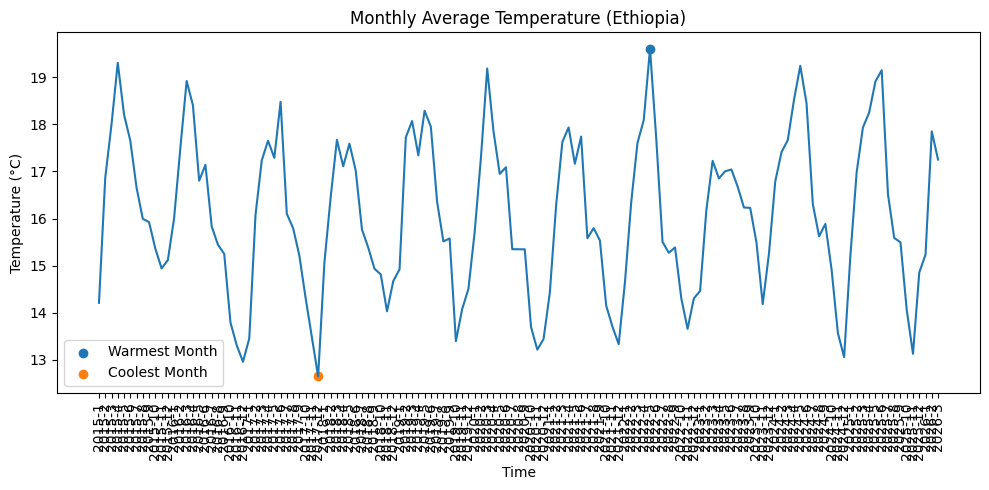

In [12]:
monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()

max_row = monthly_temp.loc[monthly_temp["T2M"].idxmax()]
min_row = monthly_temp.loc[monthly_temp["T2M"].idxmin()]

plt.figure(figsize=(10,5))
plt.plot(monthly_temp["YEAR"].astype(str) + "-" + monthly_temp["Month"].astype(str),
         monthly_temp["T2M"])

plt.scatter(max_row.name, max_row["T2M"], label="Warmest Month")
plt.scatter(min_row.name, min_row["T2M"], label="Coolest Month")

plt.xticks(rotation=90)
plt.title("Monthly Average Temperature (Ethiopia)")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

Temperature exhibits clear seasonal variation. The warmest months occur during dry periods, while cooler temperatures align with wetter months, reflecting the influence of rainfall and cloud cover on temperature.

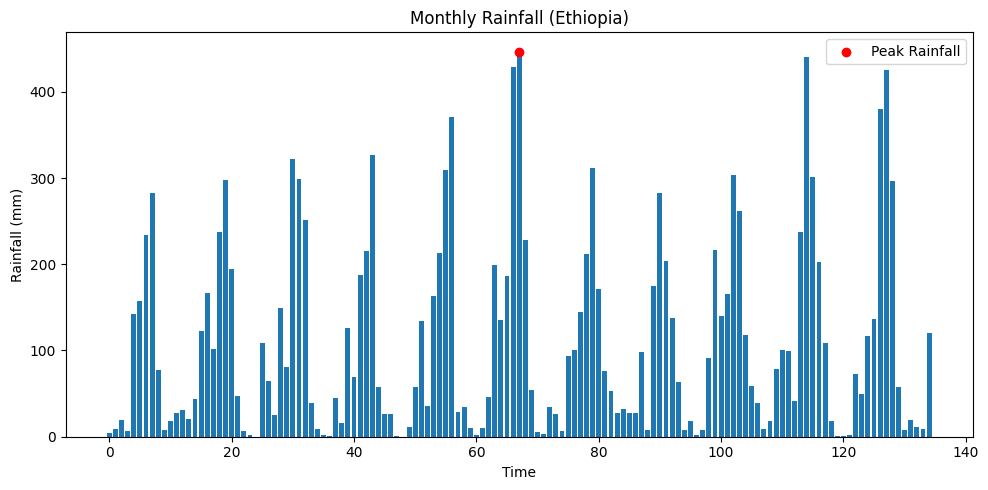

In [13]:
monthly_rain = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()

peak_rain = monthly_rain.loc[monthly_rain["PRECTOTCORR"].idxmax()]

plt.figure(figsize=(10,5))
plt.bar(range(len(monthly_rain)), monthly_rain["PRECTOTCORR"])

plt.scatter(peak_rain.name, peak_rain["PRECTOTCORR"], color='red', label="Peak Rainfall")

plt.title("Monthly Rainfall (Ethiopia)")
plt.xlabel("Time")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.show()

# Rainfall Trends
Rainfall is strongly seasonal, with distinct peaks indicating the main rainy season. Most months receive low precipitation, highlighting prolonged dry periods.

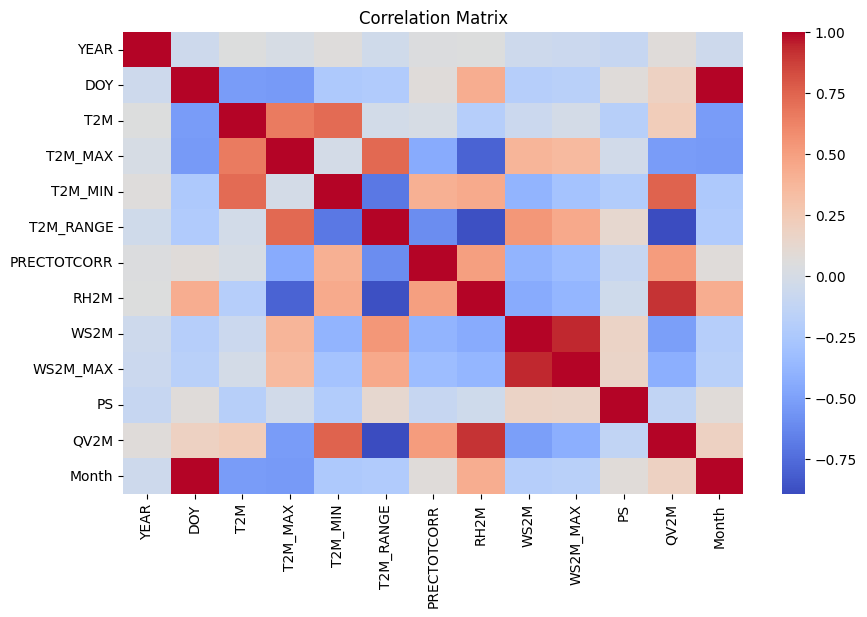

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [15]:
corr = df.corr(numeric_only=True)

corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]

corr_pairs.head(10)

DOY        Month        0.996557
Month      DOY          0.996557
WS2M_MAX   WS2M         0.940826
WS2M       WS2M_MAX     0.940826
RH2M       QV2M         0.904901
QV2M       RH2M         0.904901
T2M_MIN    QV2M         0.753414
QV2M       T2M_MIN      0.753414
T2M_MAX    T2M_RANGE    0.731151
T2M_RANGE  T2M_MAX      0.731151
dtype: float64

The strongest relationships observed are:

- WS2M and WS2M_MAX show a strong positive correlation, indicating that higher average wind speeds correspond to stronger maximum gusts.
- QV2M and RH2M are highly correlated, showing that increased atmospheric moisture leads to higher humidity levels.
- T2M and T2M_MAX are strongly correlated, as higher average temperatures are associated with higher daily maximum temperatures.

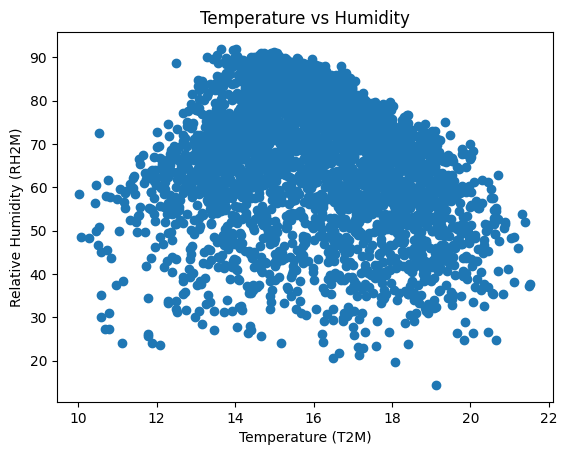

In [16]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("Temperature vs Humidity")
plt.show()


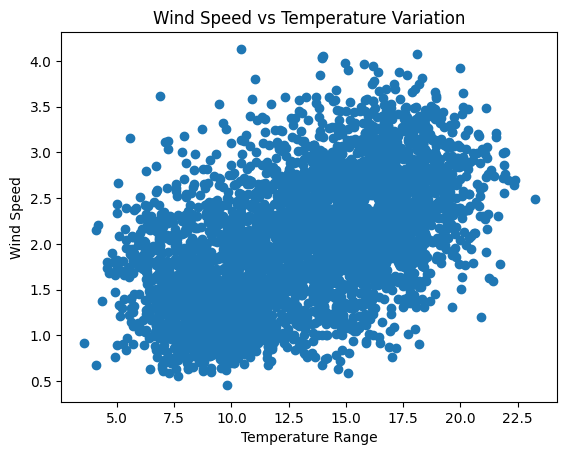

In [17]:
plt.figure()
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.title("Wind Speed vs Temperature Variation")
plt.show()

A mild inverse relationship is observed between temperature and humidity, suggesting that hotter conditions tend to be drier. Wind speed shows limited direct correlation with temperature variability.

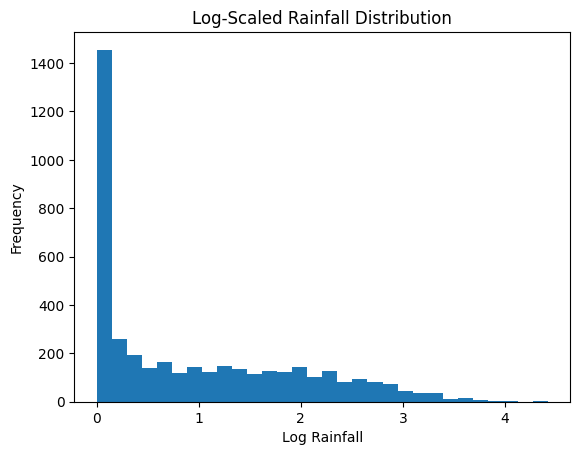

In [18]:
plt.figure()
plt.hist(np.log1p(df["PRECTOTCORR"]), bins=30)
plt.title("Log-Scaled Rainfall Distribution")
plt.xlabel("Log Rainfall")
plt.ylabel("Frequency")
plt.show()

Rainfall distribution is highly skewed, with many low-rainfall days and a few extreme events. Applying a log transformation reveals a more balanced distribution and improves interpretability.

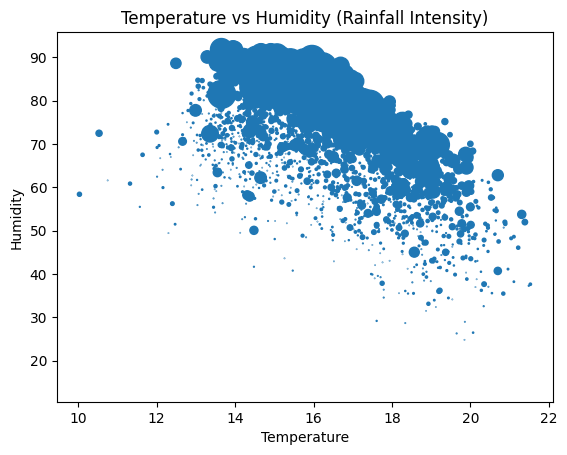

In [19]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Temperature vs Humidity (Rainfall Intensity)")
plt.show()

Higher rainfall intensity tends to occur under moderate temperature and higher humidity conditions, reflecting the interaction between atmospheric moisture and precipitation.

In [20]:
df.to_csv("../data/ethiopia_clean.csv", index=False)